# dfdraw Example Gallery

**Version:** Phase 13.16.DF v1.0 (refreshed Phase 13.17.DF)
**Tests:** 451 passing across 43 features, 21 invariance tests

This notebook mirrors `examples/generate_gallery.py` cell-by-cell. Each of the
10 examples is a self-contained demonstration of a dfdraw feature, using
ALICE-flavored synthetic data (pt/eta/phi/dE/dx/ITS residuals/TPC sectors).

**How to use this notebook:**

- **Run all cells** to see all 10 examples rendered inline.
- **Modify a single cell** to experiment with a feature — each cell is
  self-contained.
- **Run via pytest** for CI verification:
  `pytest --nbmake examples/dfdraw_gallery.ipynb`
- **Or via nbconvert:**
  `jupyter nbconvert --to notebook --execute examples/dfdraw_gallery.ipynb`

**Source of truth:** `examples/generate_gallery.py`. If the notebook and
script diverge, regenerate the notebook from the script — do not edit the
notebook cells manually.

**For full API documentation, see:**

- `docs/README.md` — user guide
- `docs/API_REFERENCE.md` — API reference
- `docs/dfdraw_Technical_Summary.md` — technical reference


## Setup

Imports and environment configuration. Same per-example seeds as
`generate_gallery.py`, so figures in this notebook are byte-identical
(modulo matplotlib version) to the gallery PNGs in `docs/examples/`.


In [1]:
import os
import sys
import numpy as np
import pandas as pd

# Ensure dfdraw is importable when running from examples/ or repo root
# Notebook location: dfdraw/examples/dfdraw_gallery.ipynb
notebook_dir = os.path.abspath('.')
if os.path.basename(notebook_dir) == 'examples':
    dfdraw_dir = os.path.dirname(notebook_dir)
else:
    dfdraw_dir = notebook_dir
dfextensions_dir = os.path.dirname(dfdraw_dir)
for path in [dfextensions_dir, dfdraw_dir]:
    if path not in sys.path:
        sys.path.insert(0, path)

import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

from dfdraw import DFDraw, set_style

# Per-example seeds (same as generate_gallery.py)
SEEDS = {
    '01': 42,  '02': 101, '03': 202, '04': 303, '05': 404,
    '06': 505, '07': 606, '08': 707, '09': 808, '10': 909,
}

print(f'dfdraw Example Gallery — Phase 13.16.DF')
print(f'Matplotlib backend: {matplotlib.get_backend()}')


dfdraw Example Gallery — Phase 13.16.DF
Matplotlib backend: module://matplotlib_inline.backend_inline


## Synthetic ALICE Data Generators

These functions produce ALICE-flavored synthetic data. You can reuse them
in your own experiments — they're deliberately simple so you can see how
the distributions are constructed.


In [2]:
def make_tpc_tracks(n, seed, particle_types=('hadron', 'muon', 'electron')):
    """Generate synthetic TPC track data with physically-plausible distributions."""
    rng = np.random.RandomState(seed)
    pt = np.clip(rng.exponential(2.0, n) + 0.1, 0.1, 20.0)
    eta = rng.uniform(-1.0, 1.0, n)
    phi = rng.uniform(-np.pi, np.pi, n)
    p = pt * np.cosh(eta)
    type_probs = np.array([0.70, 0.20, 0.10][:len(particle_types)])
    type_probs /= type_probs.sum()
    ptype = rng.choice(particle_types, size=n, p=type_probs)
    mass = np.where(ptype == 'hadron', 0.938,
                    np.where(ptype == 'muon', 0.106, 0.000511))
    beta = p / np.sqrt(p**2 + mass**2)
    dedx = np.clip(2.0 / (beta**2 + 0.05) + rng.normal(0, 0.3, n), 0.5, 20.0)
    quality = np.clip(rng.beta(5, 2, n), 0, 1)
    nHits = rng.randint(60, 160, n)
    chi2 = rng.exponential(1.0, n) + 0.5
    sector = rng.randint(0, 18, n)
    return pd.DataFrame({
        'pt': pt, 'eta': eta, 'phi': phi, 'p': p, 'dEdx': dedx,
        'quality': quality, 'nHits': nHits, 'chi2': chi2,
        'particle_type': ptype, 'sector': sector,
    })


def make_its_residuals(n, seed):
    """Generate 6-layer ITS residual data with layer-dependent bias/spread."""
    rng = np.random.RandomState(seed)
    stave = rng.randint(0, 48, n)
    layer_biases = [0.00, 0.02, -0.01, 0.03, -0.02, 0.01]
    layer_sigmas = [0.05, 0.06, 0.08, 0.10, 0.12, 0.14]
    data = {'staveITS': stave}
    for layer_idx in range(6):
        systematic = 0.03 * np.sin(2 * np.pi * stave / 48 + layer_idx * np.pi / 3)
        noise = rng.normal(layer_biases[layer_idx], layer_sigmas[layer_idx], n)
        data[f'dd_dyITS{layer_idx}'] = systematic + noise
    return pd.DataFrame(data)


def make_pull_data(n, seed, sigma_bias=1.0):
    """Generate pull distribution; sigma_bias != 1.0 simulates error bar mis-calibration."""
    rng = np.random.RandomState(seed)
    return pd.DataFrame({'pull': rng.randn(n) * sigma_bias})


## Example 01 — 1D Histogram with `auto_title`

**Feature:** Basic 1D histogram with expression-derived automatic title
(Phase 13.12.DF v1.2).

**Data:** pt distribution of 20,000 synthetic TPC tracks.

**Key API:** `drawer.hist(expr, auto_title=True)` — the title is generated
from the expression and selection automatically.


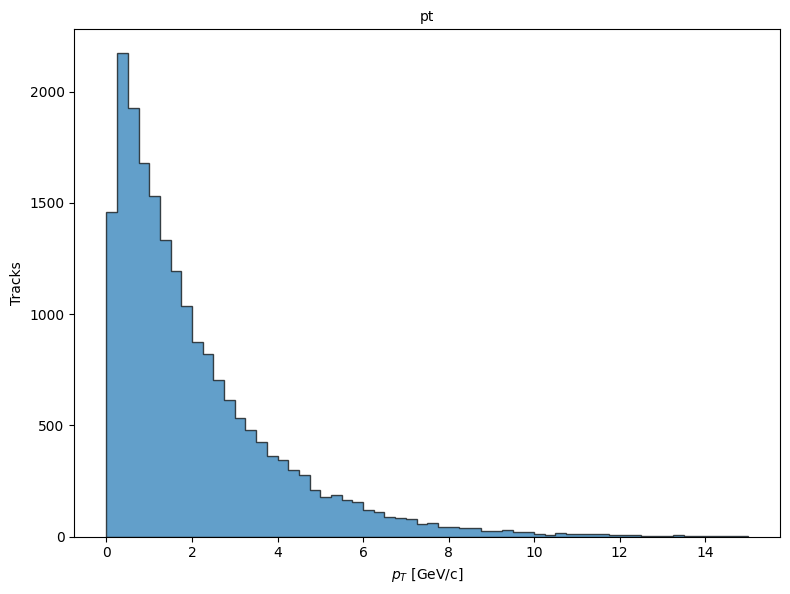

In [3]:
df = make_tpc_tracks(20000, SEEDS['01'])
drawer = DFDraw(df)
fig, ax, stats = drawer.hist('pt', bins=60, range=(0, 15), auto_title=True)
ax.set_xlabel('$p_T$ [GeV/c]')
ax.set_ylabel('Tracks')
plt.show()


## Example 02 — `group_by` Overlay

**Feature:** Multiple histograms overlaid on the same axes, grouped by a
categorical column.

**Data:** pt distribution split by particle type (hadron / muon / electron).

**Key API:** `drawer.hist(expr, group_by='particle_type')` — automatic color
cycling and legend.


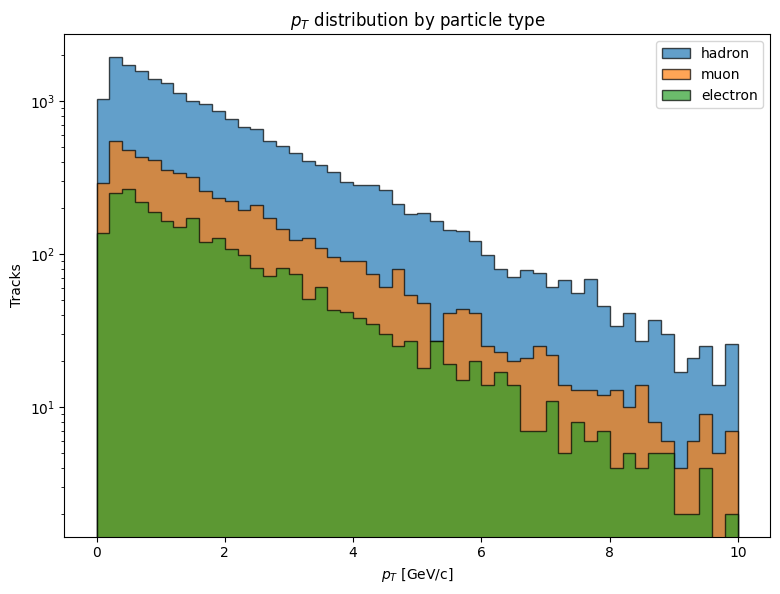

In [4]:
df = make_tpc_tracks(30000, SEEDS['02'])
drawer = DFDraw(df)
fig, ax, stats = drawer.hist(
    'pt', bins=50, range=(0, 10),
    group_by='particle_type',
    title='$p_T$ distribution by particle type',
)
ax.set_xlabel('$p_T$ [GeV/c]')
ax.set_ylabel('Tracks')
ax.set_yscale('log')
plt.show()


## Example 03 — Scatter with Continuous Color Mapping

**Feature:** Scatter plot with continuous color encoding a third variable.

**Data:** dE/dx vs momentum, colored by track quality (a Beta(5,2)
distributed QA score).

**Key API:** `drawer.scatter('dEdx:p', color='quality')` — `color=` accepts
a column name for continuous mapping.


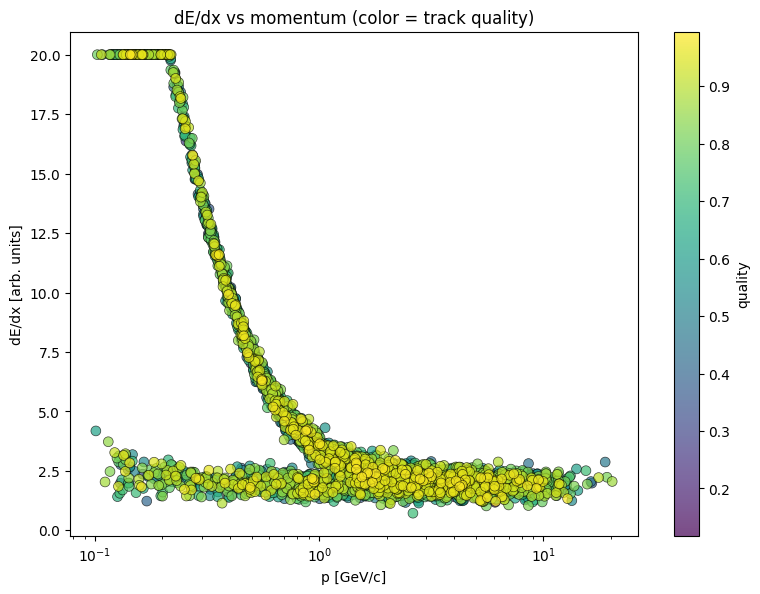

In [5]:
df = make_tpc_tracks(5000, SEEDS['03'])
df = df.sort_values('quality')  # draw high-quality on top
drawer = DFDraw(df)
fig, ax, stats = drawer.scatter(
    'dEdx:p',
    color='quality',
    title='dE/dx vs momentum (color = track quality)',
)
ax.set_xlabel('p [GeV/c]')
ax.set_ylabel('dE/dx [arb. units]')
ax.set_xscale('log')
plt.show()


## Example 04 — Profile vs Scatter Side-by-Side

**Feature:** Demonstrate the difference between raw scatter and binned
profile on the same data.

**Data:** dE/dx vs p for 15,000 tracks.

**Key API:** `drawer.profile(expr, bins=N)` returns the mean per x-bin with
error bars — essentially a cleaner summary of the scatter cloud.

The scatter shows the raw density; the profile shows `<dE/dx>` per bin with
standard error of the mean. The Bethe-Bloch-like shape emerges cleanly in
the profile even though the scatter has significant spread.


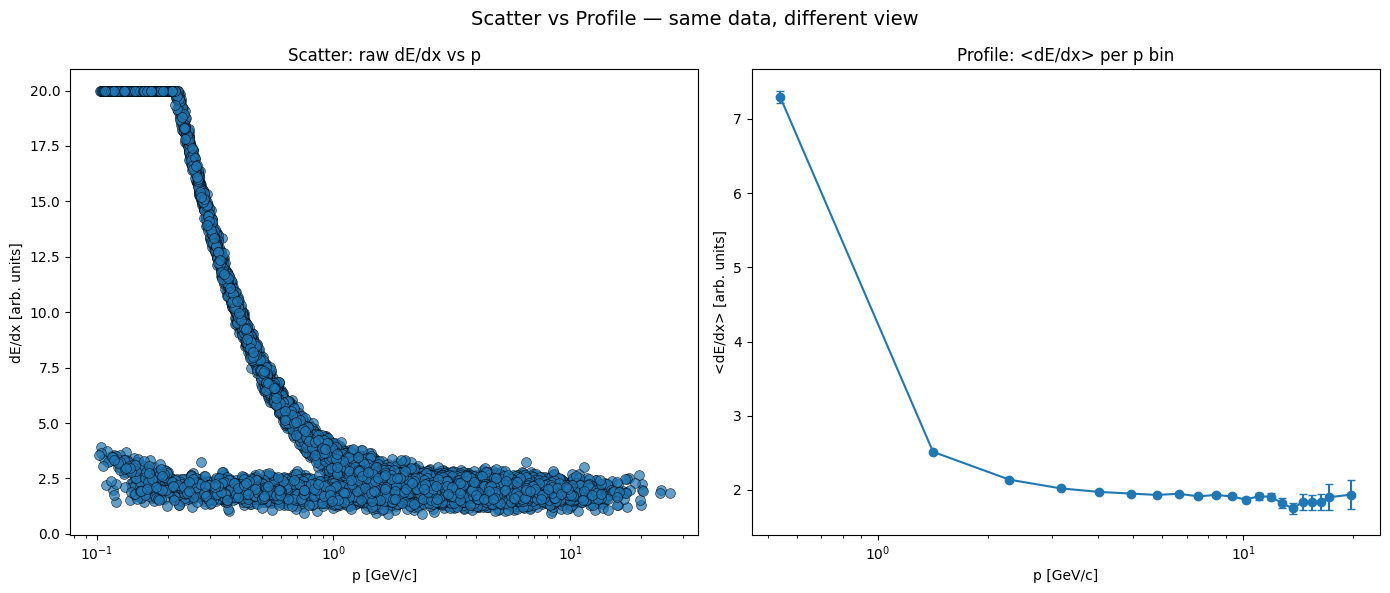

In [6]:
df = make_tpc_tracks(15000, SEEDS['04'])
drawer = DFDraw(df)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

drawer.scatter('dEdx:p', ax=axes[0], title='Scatter: raw dE/dx vs p')
axes[0].set_xlabel('p [GeV/c]')
axes[0].set_ylabel('dE/dx [arb. units]')
axes[0].set_xscale('log')

drawer.profile('dEdx:p', ax=axes[1], bins=30, title='Profile: <dE/dx> per p bin')
axes[1].set_xlabel('p [GeV/c]')
axes[1].set_ylabel('<dE/dx> [arb. units]')
axes[1].set_xscale('log')

fig.suptitle('Scatter vs Profile — same data, different view', fontsize=14)
plt.tight_layout()
plt.show()


## Example 05 — 2D Density: `hist2d` vs `hexbin`

**Feature:** Two ways to visualize 2D density — rectangular binning
(`hist2d`) and hexagonal binning (`hexbin`).

**Data:** η vs φ acceptance for 50,000 tracks (approximately uniform).

**When to use which:**
- `hist2d` — standard grid; simpler interpretation; good for ≤10⁵ points
- `hexbin` — less aliasing; better for large datasets; better visual
  isotropy


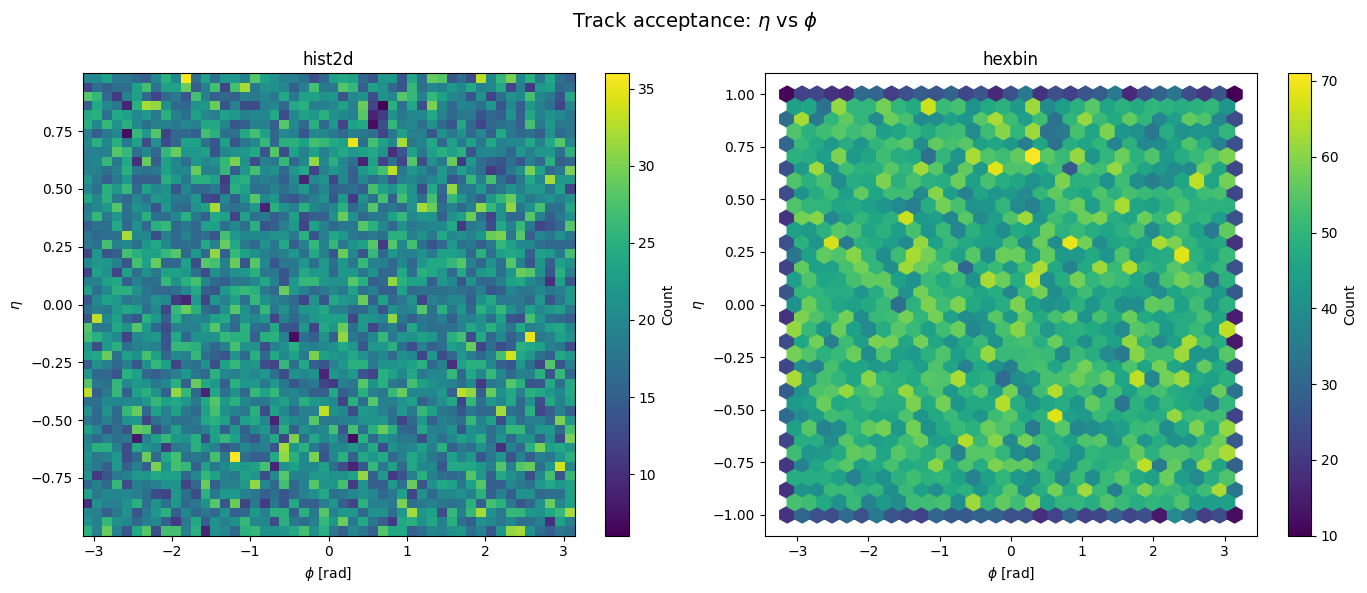

In [7]:

df = make_tpc_tracks(50000, SEEDS['05'])
drawer = DFDraw(df)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

drawer.hist2d('eta:phi', ax=axes[0], bins=[50, 50], title='hist2d')
axes[0].set_xlabel(r'$\phi$ [rad]')
axes[0].set_ylabel(r'$\eta$')

drawer.hexbin('eta:phi', ax=axes[1], gridsize=30, title='hexbin')
axes[1].set_xlabel(r'$\phi$ [rad]')
axes[1].set_ylabel(r'$\eta$')

fig.suptitle(r'Track acceptance: $\eta$ vs $\phi$', fontsize=14)
plt.tight_layout()
plt.show()


## Example 06 — `same=True` Superposition (Phase 13.13.DF)

**Feature:** Overlay multiple plots on the same axes across different
`DFDraw` instances using `same=True`.

**Data:** pt distribution for three particle species, drawn separately and
superimposed.

**Key API:** the first call creates the axes; subsequent calls with
`same=True` reuse them with auto-color cycling and auto-labels.

**Note:** this example uses three separate `DFDraw` instances (one per
species DataFrame) because the data is filtered before plotting. For
multi-column overlays on the _same_ DataFrame, prefer vector expression
syntax (see Example 08) — it's a single call with correct color semantics.


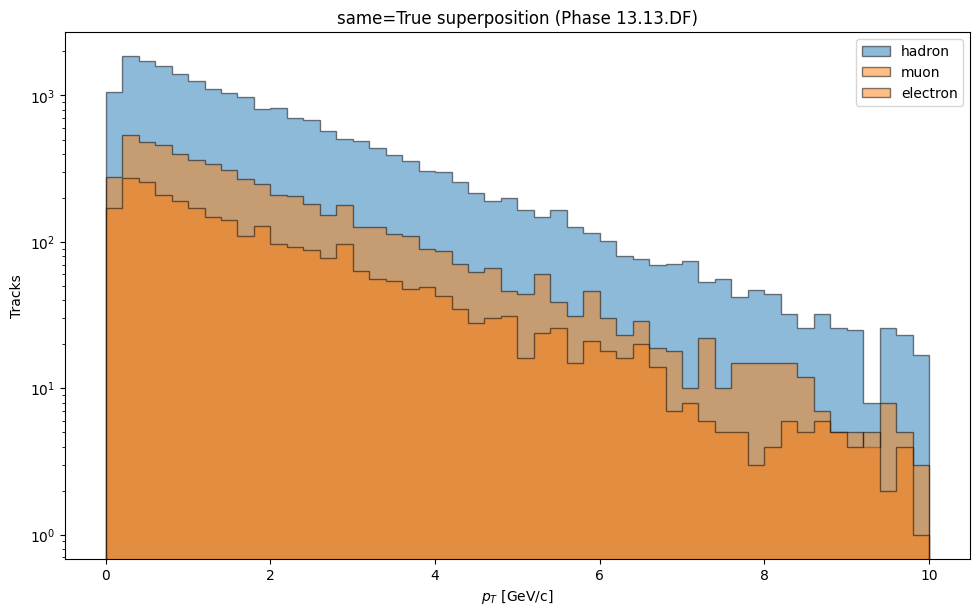

In [8]:
df = make_tpc_tracks(30000, SEEDS['06'])

df_hadron = df[df['particle_type'] == 'hadron']
df_muon = df[df['particle_type'] == 'muon']
df_electron = df[df['particle_type'] == 'electron']

fig, ax = plt.subplots(figsize=(10, 6))

DFDraw(df_hadron).hist('pt', bins=50, range=(0, 10), ax=ax,
                       label='hadron', alpha=0.5)
DFDraw(df_muon).hist('pt', bins=50, range=(0, 10), ax=ax,
                     label='muon', alpha=0.5, same=True)
DFDraw(df_electron).hist('pt', bins=50, range=(0, 10), ax=ax,
                         label='electron', alpha=0.5, same=True)

ax.set_xlabel('$p_T$ [GeV/c]')
ax.set_ylabel('Tracks')
ax.set_title('same=True superposition (Phase 13.13.DF)')
ax.set_yscale('log')
ax.legend()
plt.show()


## Example 07 — Facet Grid

**Feature:** `facet=True` produces a subplot grid instead of an overlay,
one panel per group.

**Data:** dy residuals for 4 TPC sectors (sectors 0, 4, 9, 13). Each sector
has a different injected bias simulating calibration imperfection.

**Key API:** `drawer.hist(expr, group_by='sector', facet=True, ncols=2)` —
creates a 2×N grid automatically.


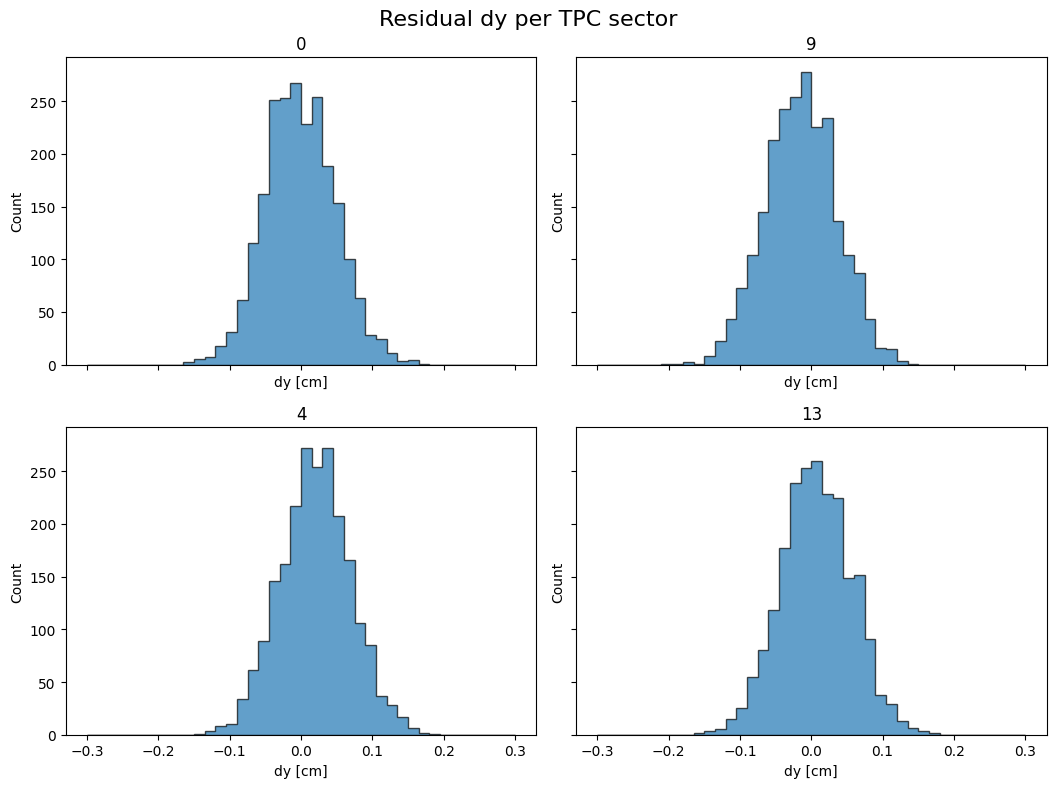

In [9]:
df = make_tpc_tracks(40000, SEEDS['07'])
df = df[df['sector'].isin([0, 4, 9, 13])].copy()
rng = np.random.RandomState(SEEDS['07'] + 1)
bias_by_sector = {0: 0.0, 4: 0.02, 9: -0.015, 13: 0.008}
df['dy'] = df['sector'].map(bias_by_sector) + rng.normal(0, 0.05, len(df))

drawer = DFDraw(df)
fig, axes, stats = drawer.hist(
    'dy', bins=40, range=(-0.3, 0.3),
    group_by='sector', facet=True, ncols=2,
    title='Residual dy per TPC sector',
)
for ax in np.atleast_1d(axes).flatten():
    ax.set_xlabel('dy [cm]')
plt.show()


## Example 08 — Vector Expression ITS (AD-37 Fix) ⭐

**THE centerpiece example.** Phase 13.16.DF introduced vector expressions
specifically to fix a production bug (AD-37) that affected ITS layer
residual plots.

### The Bug (BEFORE)

Before Phase 13.16.DF, the natural way to overlay 6 ITS layer residuals
was a scalar `same=True` loop:

```python
for layer in range(6):
    aDF.draw(f'dd_dyITS{layer}:staveITS', type='profile', same=(layer>0))
```

But `aDF.draw()` creates a **fresh `DFDraw` instance per call**, which
resets the color cycle on every iteration. Result: only 2 colors appeared
for 6 layers (the first color, then everything defaulting to the second).
**This is the AD-37 bug.**

### The Fix (AFTER)

Phase 13.16.DF introduced bracket-vector syntax. A single call with a
vector expression handles all 6 layers within one `DFDraw` instance's
lifetime, so the color cycle is preserved:

```python
drawer.profile('[dd_dyITS0,dd_dyITS1,dd_dyITS2,dd_dyITS3,dd_dyITS4,dd_dyITS5]:staveITS',
               bins=12)
```

Result: 6 distinct colors, single call, automatic legend.

**The cell below produces a two-panel figure showing both — the broken
scalar-loop pattern on the left, the vector expression fix on the right.**


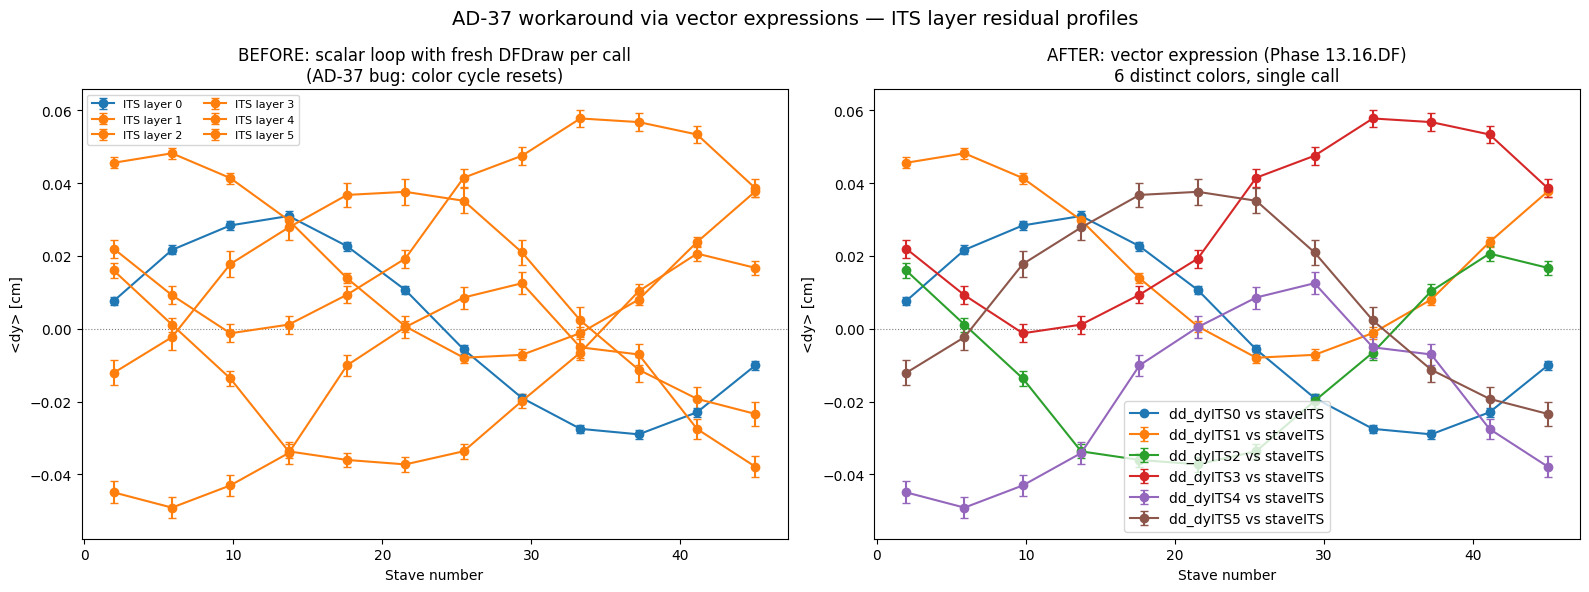

In [10]:
df = make_its_residuals(20000, SEEDS['08'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- LEFT: broken pattern (pre-Phase-13.16.DF) ---
# Fresh DFDraw per iteration reproduces the AD-37 color-reset behavior
for layer in range(6):
    drawer_fresh = DFDraw(df)
    drawer_fresh.profile(
        f'dd_dyITS{layer}:staveITS',
        ax=axes[0],
        bins=12,
        label=f'ITS layer {layer}',
        same=(layer > 0),
    )
axes[0].set_title(
    'BEFORE: scalar loop with fresh DFDraw per call\n'
    '(AD-37 bug: color cycle resets)'
)
axes[0].set_xlabel('Stave number')
axes[0].set_ylabel('<dy> [cm]')
axes[0].legend(fontsize=8, ncol=2)
axes[0].axhline(0, color='gray', linestyle=':', linewidth=0.8)

# --- RIGHT: vector expression fix (Phase 13.16.DF) ---
drawer = DFDraw(df)
drawer.profile(
    '[dd_dyITS0,dd_dyITS1,dd_dyITS2,dd_dyITS3,dd_dyITS4,dd_dyITS5]:staveITS',
    ax=axes[1],
    bins=12,
)
axes[1].set_title(
    'AFTER: vector expression (Phase 13.16.DF)\n'
    '6 distinct colors, single call'
)
axes[1].set_xlabel('Stave number')
axes[1].set_ylabel('<dy> [cm]')
axes[1].axhline(0, color='gray', linestyle=':', linewidth=0.8)

fig.suptitle(
    'AD-37 workaround via vector expressions — ITS layer residual profiles',
    fontsize=14
)
plt.tight_layout()
plt.show()


### What you should see

- **Left panel:** only 2 colors are used for the 6 ITS layers — layer 0 in
  one color (typically blue), and layers 1–5 all in a second color
  (typically orange). This is the AD-37 bug reproduced.
- **Right panel:** all 6 layers in 6 distinct colors, with an automatic
  legend listing each `dd_dyITSi vs staveITS`.

The right panel is what you get by writing vector expressions. The left
panel is what happens if you write a scalar loop across fresh `DFDraw`
instances — which is exactly what `aDF.draw()` loops produce, hence the
AD-37 bug.

**Recommendation:** for N-series overlays through `AliasDataFrame`, always
use the vector form. See the README "Vector Expressions" section for full
broadcasting rules and the `aDF.draw()` Mode 2 section for ADF-specific
guidance.


## Example 09 — Batch QA Dashboard

**Feature:** Produce a multi-panel QA dashboard from a specification dict.

**Data:** TPC track data for a typical calibration QA pass: pt
distribution, η/φ acceptance, dE/dx profile, χ²/ndf distribution.

**Key API:** `drawer.draw_batch(specs, ...)` accepts a dict of plot specs
and produces each one. Phase 13.14.DF added group format with defaults
cascade and subplot-grid layouts.

The example below uses a manual `plt.subplots` 2×2 grid for maximum
portability across dfdraw versions. The `draw_batch` group format API
varies slightly between minor versions, so the gallery uses the explicit
approach that works everywhere.


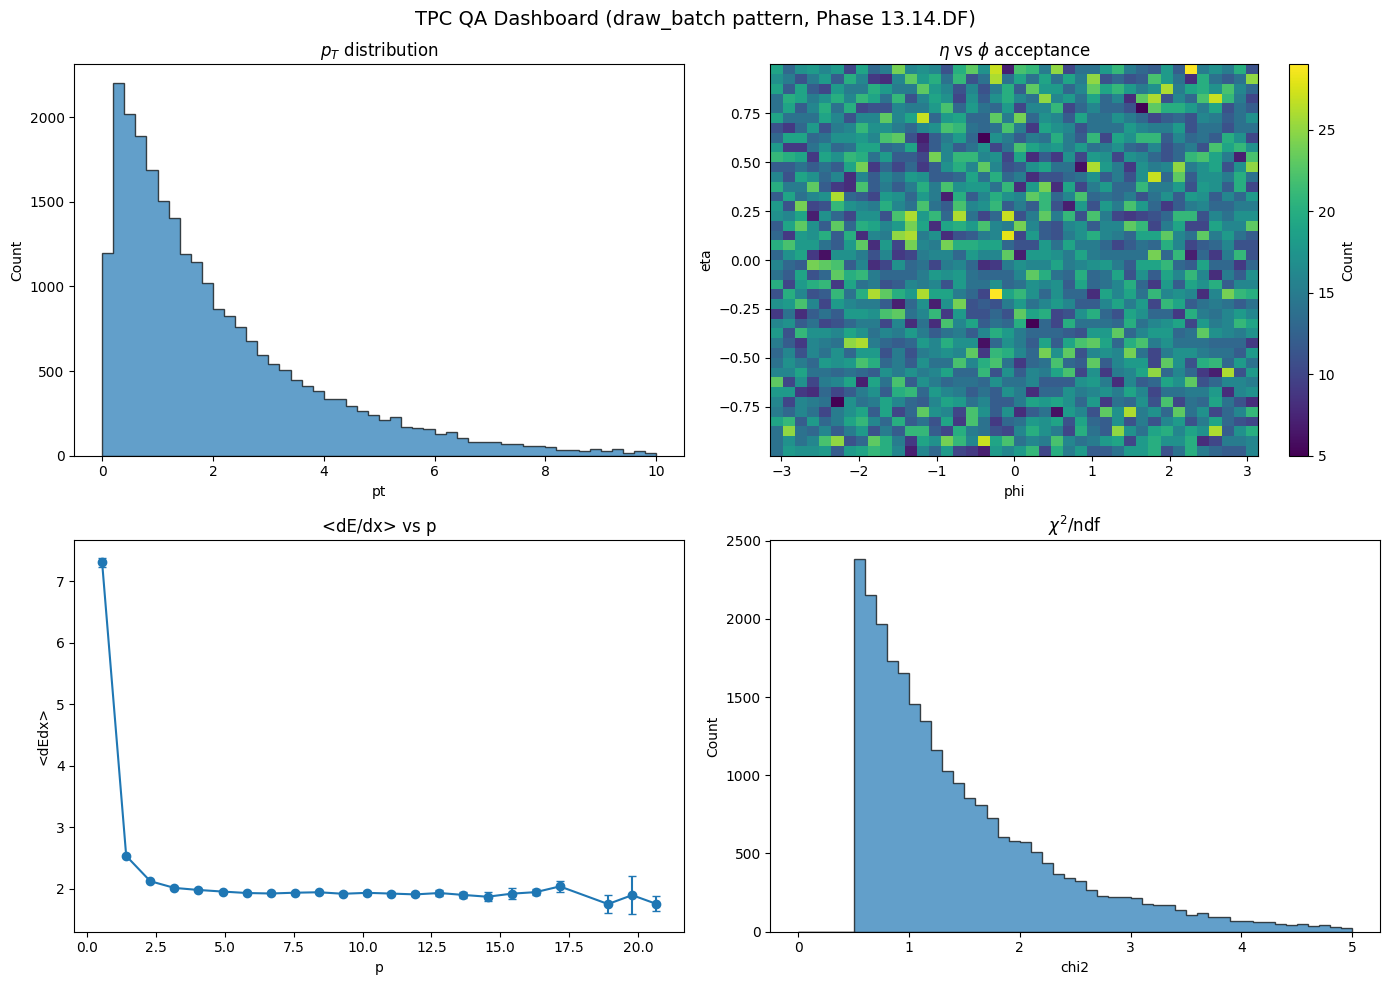

In [11]:

df = make_tpc_tracks(25000, SEEDS['09'])
drawer = DFDraw(df)

specs = {
    'pt_dist': {
        'expr': 'pt', 'type': 'hist',
        'bins': 50, 'range': (0, 10),
        'title': '$p_T$ distribution',
    },
    'eta_phi': {
        'expr': 'eta:phi', 'type': 'hist2d',
        'bins': [40, 40],
        'title': r'$\eta$ vs $\phi$ acceptance',
    },
    'dedx_p': {
        'expr': 'dEdx:p', 'type': 'profile',
        'bins': 30,
        'title': '<dE/dx> vs p',
    },
    'chi2_dist': {
        'expr': 'chi2', 'type': 'hist',
        'bins': 50, 'range': (0, 5),
        'title': r'$\chi^2/\mathrm{ndf}$',
    },
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ax_iter = iter(axes.flatten())

for name, spec in specs.items():
    ax = next(ax_iter)
    plot_type = spec.pop('type')
    expr = spec.pop('expr')
    method = getattr(drawer, plot_type)
    method(expr, ax=ax, **spec)

fig.suptitle('TPC QA Dashboard (draw_batch pattern, Phase 13.14.DF)', fontsize=14)
plt.tight_layout()
plt.show()


## Example 10 — Pull Distribution with Gaussian Reference + Stats Box

**Feature:** Classic QA pattern for validating error bar calibration. Pull
values should follow N(0, 1) if errors are correctly estimated.

**Data:** 15,000 pull values with a deliberately injected 5% sigma bias
(σ = 1.05 instead of 1.0) — simulating under-estimated error bars.

**Key APIs:**
- `drawer.add_reference_overlay(ax, func='gaussian', mu=0, sigma=1)` —
  overlays a Gaussian curve scaled to the histogram
- `drawer.add_statistics_box(ax, values, expected_mean=0, expected_std=1)` —
  annotation box showing n, μ, σ and deviations from expected values

**What you should see:** the stats box should show Δσ ≈ +0.05 (σ ≈ 1.05
vs expected 1.0), confirming the injected bias. Δμ should be near zero
(the bias is in sigma, not mean).


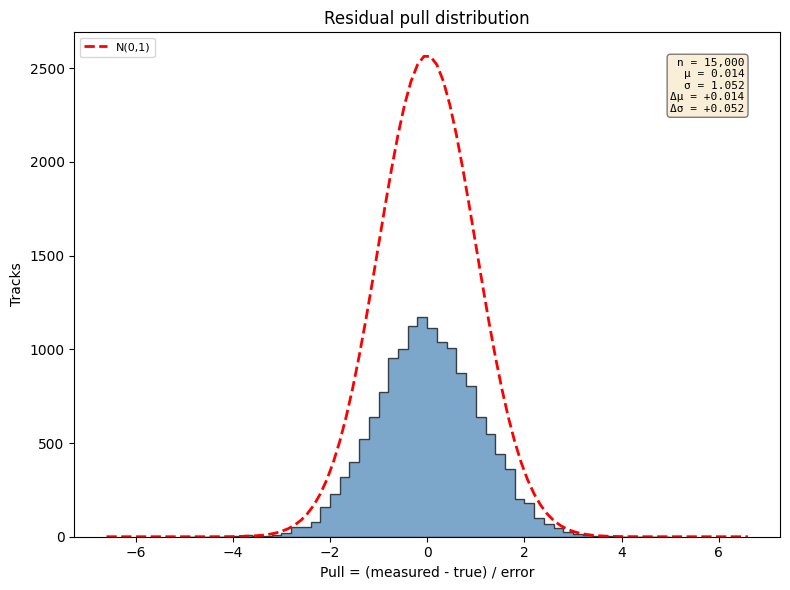

In [12]:
df = make_pull_data(15000, SEEDS['10'], sigma_bias=1.05)

drawer = DFDraw(df)
fig, ax, stats = drawer.hist(
    'pull', bins=50, range=(-5, 5),
    title='Residual pull distribution',
    color='steelblue', alpha=0.7,
)

# Gaussian N(0, 1) reference curve
drawer.add_reference_overlay(ax, func='gaussian', mu=0, sigma=1,
                             color='red', linewidth=2)

# Stats box with expected values
drawer.add_statistics_box(
    ax, df['pull'].values,
    expected_mean=0.0,
    expected_std=1.0,
    position='upper right',
)

ax.set_xlabel('Pull = (measured - true) / error')
ax.set_ylabel('Tracks')
plt.show()


## Summary

This notebook demonstrated 10 dfdraw features spanning Phases 13.6.G.DF
through 13.16.DF:

| # | Feature | Phase |
|---|---------|-------|
| 01 | 1D histogram with `auto_title` | 13.12.DF v1.2 |
| 02 | `group_by` overlay | earlier |
| 03 | Scatter with continuous color | earlier |
| 04 | Profile vs scatter comparison | earlier |
| 05 | `hist2d` vs `hexbin` | earlier |
| 06 | `same=True` superposition | 13.13.DF |
| 07 | `facet=True` grid | earlier |
| 08 | **Vector expression (AD-37 fix)** | **13.16.DF** |
| 09 | Batch QA dashboard | 13.14.DF |
| 10 | Pull distribution with reference + stats | 13.6.G.DF / earlier |

### Next Steps

- **Read the user guide:** `docs/README.md`
- **Browse the API reference:** `docs/API_REFERENCE.md`
- **Understand the phase history:** `docs/PHASE_HISTORY.md`
- **Run the test suite:** `bash run_tests.sh` (451 tests, 43 features,
  21 invariance tests)
- **Generate static PNGs:** `python examples/generate_gallery.py`

### CI Verification

To verify this notebook runs cleanly as part of testing:

```bash
# Option 1: via pytest plugin nbmake
pytest --nbmake examples/dfdraw_gallery.ipynb

# Option 2: via jupyter nbconvert
jupyter nbconvert --to notebook --execute examples/dfdraw_gallery.ipynb \
    --output /tmp/dfdraw_gallery_executed.ipynb
```

Either approach catches API drift automatically — a failing cell is a
failing test.
